# CNN v1 — from scratch (Maxime)

CNN construit à la main, à comparer au CNN de `keras_v2_avec_gradcam.ipynb` (Cyril).
Mêmes données et même taille d'image pour rester comparable ; trois différences principales :

1. **3 blocs convolutifs** (32 → 64 → 128 filtres) au lieu d'un seul ;
2. **GlobalAveragePooling2D** au lieu d'un `Flatten` géant (≈86 M paramètres chez Cyril) ;
3. **`class_weight`** en plus de l'augmentation, et **`shuffle=True`** sur le train.

Objectif principal : améliorer le **rappel de la classe COVID**, qui plafonne à **0.39** chez Cyril.

In [1]:
import tensorflow as tf
print("GPU disponible :", tf.config.list_physical_devices('GPU'))
print("Version TensorFlow :", tf.__version__)

GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Version TensorFlow : 2.10.0


Si la liste ci-dessus est vide, aucun GPU n'est détecté et l'entraînement se fera sur CPU — plus lent, mais fonctionnel.

C'est le cas attendu ici : ce PC a une carte AMD, qui passe par DirectML et non par CUDA, donc elle n'apparaît pas dans `list_physical_devices('GPU')` avec un TensorFlow standard.

## 1. Imports

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Dropout, Dense,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline

## 2. Chargement des données

Mêmes dossiers que Cyril, images 299×299 en niveaux de gris, labels inférés depuis les noms de dossiers.

`shuffle=True` sur le train (Cyril avait `shuffle=False`, ce qui produisait des batches quasi mono-classe et dégradait la descente de gradient). `shuffle=False` sur validation et test, pour que l'ordre des prédictions corresponde à l'ordre des vrais labels au moment de l'évaluation.

In [4]:
DATA_DIR = "../../COVID-19_Radiography_Dataset_split"
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    directory=f"{DATA_DIR}/train_augmented/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    labels="inferred",
    color_mode="grayscale",
    shuffle=True,
    seed=SEED,
)

val_ds = image_dataset_from_directory(
    directory=f"{DATA_DIR}/validation/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    labels="inferred",
    color_mode="grayscale",
    shuffle=False,
)

test_ds = image_dataset_from_directory(
    directory=f"{DATA_DIR}/test/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    labels="inferred",
    color_mode="grayscale",
    shuffle=False,
)

class_names = train_ds.class_names
print("Classes :", class_names)

Found 33336 files belonging to 4 classes.
Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.
Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


Le `prefetch` recouvre le chargement des images et le calcul : utile sur CPU, sans effet sur les résultats.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_perf = train_ds.prefetch(AUTOTUNE)
val_ds_perf = val_ds.prefetch(AUTOTUNE)
test_ds_perf = test_ds.prefetch(AUTOTUNE)

## 3. Poids de classes

`train_augmented` reste déséquilibré ; on ajoute donc un `class_weight` « balanced » pour que la loss pénalise davantage les erreurs sur les classes minoritaires — en particulier **COVID**, la classe la plus mal détectée chez Cyril.

Les labels sont reconstruits depuis `file_paths` plutôt qu'en itérant sur le dataset : c'est instantané et cela évite de décoder les 33 000 images juste pour compter les classes.

In [6]:
name_to_idx = {name: i for i, name in enumerate(class_names)}
y_train = np.array([
    name_to_idx[os.path.basename(os.path.dirname(p))]
    for p in train_ds.file_paths
])

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

for i, name in enumerate(class_names):
    print(f"{name:20s} n={np.sum(y_train == i):6d}   poids={class_weight[i]:.3f}")

COVID                n=  5396   poids=1.544
Lung_Opacity         n=  9582   poids=0.870
Normal               n= 16218   poids=0.514
Viral Pneumonia      n=  2140   poids=3.894


## 4. Architecture

Trois blocs `Conv2D` (3×3, `padding='same'`, ReLU) + `MaxPooling2D` 2×2, avec un nombre de filtres croissant (32 → 64 → 128) : la profondeur permet d'apprendre des motifs plus abstraits que le bloc unique de Cyril.

Le `GlobalAveragePooling2D` réduit chaque carte d'activation à une seule valeur, ce qui fait passer l'entrée du `Dense` de ~672 000 à 128 valeurs : le modèle tient en quelques centaines de milliers de paramètres au lieu de 86 millions, et surapprend beaucoup moins.

In [7]:
model = Sequential([
    Input(shape=(*IMG_SIZE, 1), name="input"),
    Rescaling(1. / 255, name="rescaling"),

    Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_1"),
    MaxPooling2D((2, 2), name="pool_1"),

    Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_2"),
    MaxPooling2D((2, 2), name="pool_2"),

    Conv2D(128, (3, 3), padding="same", activation="relu", name="conv_3"),
    MaxPooling2D((2, 2), name="pool_3"),

    GlobalAveragePooling2D(name="gap"),
    Dropout(0.3, name="dropout_1"),
    Dense(128, activation="relu", name="dense_hidden"),
    Dropout(0.2, name="dropout_2"),
    Dense(4, activation="softmax", name="output"),
], name="cnn_v1_maxime")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cnn_v1_maxime"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 299, 299, 1)       0         
                                                                 
 conv_1 (Conv2D)             (None, 299, 299, 32)      320       
                                                                 
 pool_1 (MaxPooling2D)       (None, 149, 149, 32)      0         
                                                                 
 conv_2 (Conv2D)             (None, 149, 149, 64)      18496     
                                                                 
 pool_2 (MaxPooling2D)       (None, 74, 74, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 74, 74, 128)       73856     
                                                                 
 pool_3 (MaxPooling2D)       (None, 37, 37, 128)     

## 5. Callbacks

`EarlyStopping` arrête l'entraînement quand la `val_loss` cesse de s'améliorer pendant 5 epochs et restaure les meilleurs poids ; `ReduceLROnPlateau` divise le learning rate par 10 après 3 epochs de stagnation.

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    factor=0.1,
    verbose=1,
)

## 6. Entraînement

`epochs=50` est un plafond : l'early stopping coupera bien avant. Sur CPU, compter plusieurs minutes par epoch.

In [9]:
history = model.fit(
    train_ds_perf,
    validation_data=val_ds_perf,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
)

model.save("cnn_v1_maxime.keras")

Epoch 1/50
1042/1042 [==============================] - 26s 24ms/step - loss: 1.1740 - accuracy: 0.4474 - val_loss: 0.9386 - val_accuracy: 0.5910 - lr: 0.0010
Epoch 2/50
1042/1042 [==============================] - 22s 21ms/step - loss: 0.9612 - accuracy: 0.5755 - val_loss: 0.8163 - val_accuracy: 0.6683 - lr: 0.0010
Epoch 3/50
1042/1042 [==============================] - 22s 21ms/step - loss: 0.8553 - accuracy: 0.6201 - val_loss: 0.8947 - val_accuracy: 0.6231 - lr: 0.0010
Epoch 4/50
1042/1042 [==============================] - 22s 21ms/step - loss: 0.7719 - accuracy: 0.6468 - val_loss: 0.7678 - val_accuracy: 0.6966 - lr: 0.0010
Epoch 5/50
1042/1042 [==============================] - 22s 21ms/step - loss: 0.7255 - accuracy: 0.6693 - val_loss: 0.7856 - val_accuracy: 0.6764 - lr: 0.0010
Epoch 6/50
1042/1042 [==============================] - 21s 21ms/step - loss: 0.6996 - accuracy: 0.6803 - val_loss: 0.6563 - val_accuracy: 0.7388 - lr: 0.0010
Epoch 7/50
1042/1042 [========================

## 7. Courbes d'apprentissage

Un écart qui se creuse entre les courbes train et validation signale du surapprentissage.

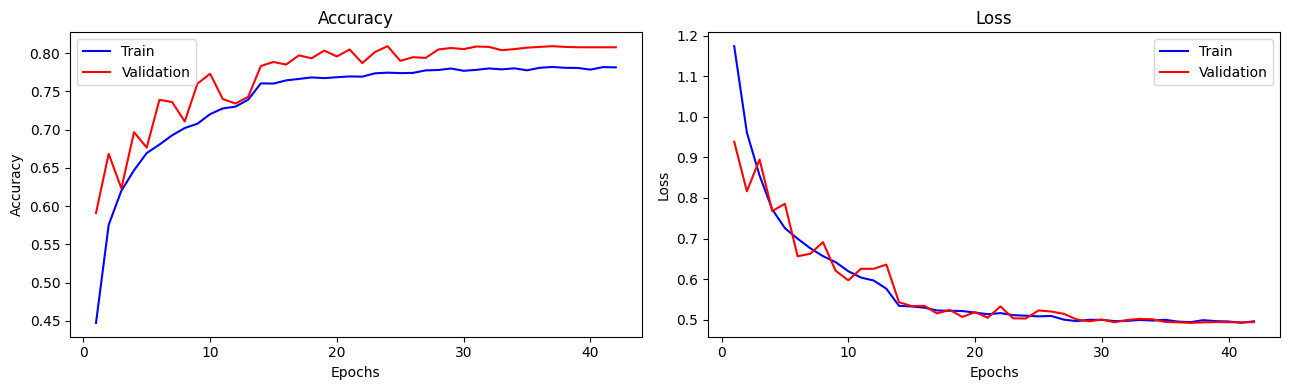

In [10]:
epochs_range = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history.history["accuracy"], label="Train", color="blue")
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation", color="red")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, history.history["loss"], label="Train", color="blue")
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation", color="red")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Évaluation

`val_ds` et `test_ds` ont été chargés avec `shuffle=False` : l'ordre des batches est stable, donc les vrais labels récupérés par itération correspondent bien, ligne à ligne, aux prédictions de `predict`.

In [11]:
def predict_and_labels(dataset, dataset_perf):
    """Renvoie (y_true, y_pred) alignés — valable seulement si dataset a shuffle=False."""
    y_pred = model.predict(dataset_perf).argmax(axis=1)
    y_true = np.concatenate([labels.numpy() for _, labels in dataset], axis=0)
    return y_true, y_pred


y_val_true, y_val_pred = predict_and_labels(val_ds, val_ds_perf)
y_test_true, y_test_pred = predict_and_labels(test_ds, test_ds_perf)

66/66 [==============================] - 1s 16ms/step


In [12]:
print("=== VALIDATION ===")
print("Accuracy :", round(accuracy_score(y_val_true, y_val_pred), 4))
print()
print(classification_report(y_val_true, y_val_pred, target_names=class_names, digits=2))

=== VALIDATION ===
Accuracy : 0.8089

                 precision    recall  f1-score   support

          COVID       0.59      0.67      0.63       338
   Lung_Opacity       0.84      0.78      0.81       598
         Normal       0.89      0.85      0.87      1013
Viral Pneumonia       0.76      0.96      0.84       134

       accuracy                           0.81      2083
      macro avg       0.77      0.82      0.79      2083
   weighted avg       0.82      0.81      0.81      2083



In [13]:
print("=== TEST ===")
print("Accuracy :", round(accuracy_score(y_test_true, y_test_pred), 4))
print()
print(classification_report(y_test_true, y_test_pred, target_names=class_names, digits=2))

=== TEST ===
Accuracy : 0.8018

                 precision    recall  f1-score   support

          COVID       0.58      0.71      0.64       337
   Lung_Opacity       0.84      0.77      0.80       599
         Normal       0.88      0.83      0.85      1014
Viral Pneumonia       0.79      0.97      0.87       134

       accuracy                           0.80      2084
      macro avg       0.77      0.82      0.79      2084
   weighted avg       0.81      0.80      0.80      2084



### Matrices de confusion

Les lignes sont les vrais labels, les colonnes les prédictions : la ligne COVID montre vers quelles classes partent les cas COVID manqués.

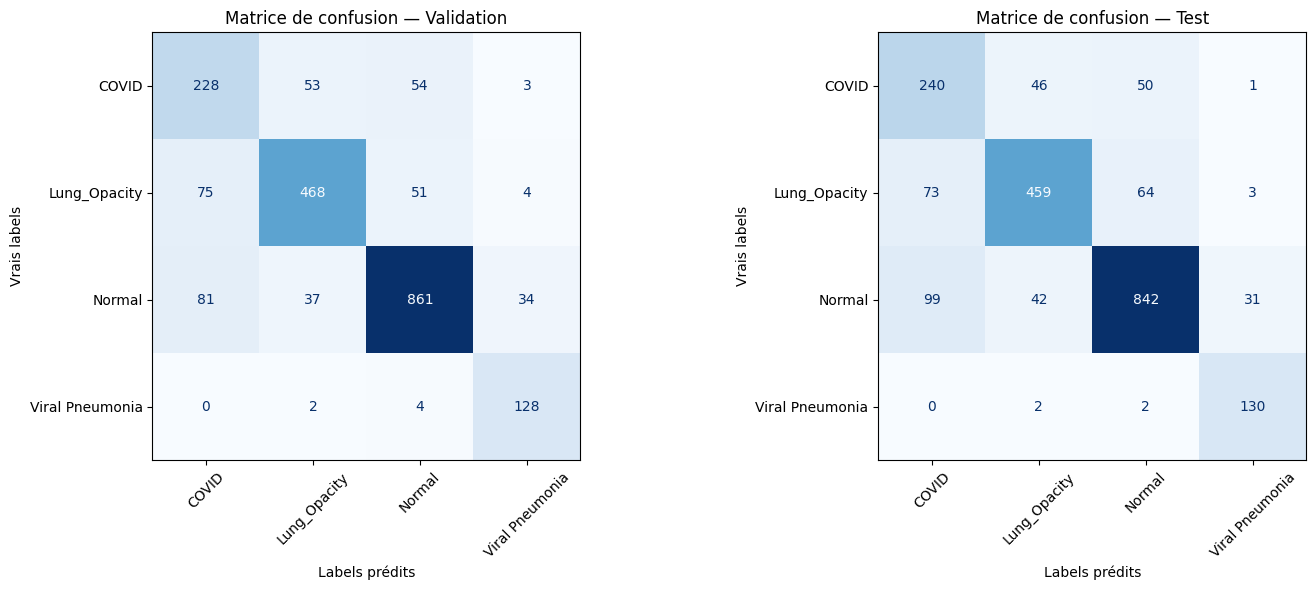

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (title, y_true, y_pred) in zip(
    axes,
    [
        ("Validation", y_val_true, y_val_pred),
        ("Test", y_test_true, y_test_pred),
    ],
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Matrice de confusion — {title}")
    ax.set_xlabel("Labels prédits")
    ax.set_ylabel("Vrais labels")

plt.tight_layout()
plt.show()

## 9. Focus sur la classe COVID

C'est le point faible du modèle de Cyril : sur le test, il obtient un **rappel de 0.39** pour COVID (précision 0.51, F1 0.44), c'est-à-dire qu'il **rate 6 cas COVID sur 10**. Dans un contexte de dépistage, ce sont les faux négatifs qui coûtent le plus cher, donc le rappel COVID est notre métrique de référence — bien plus que l'accuracy globale, tirée vers le haut par la classe Normal, majoritaire.

La cellule ci-dessous isole ce rappel et le compare explicitement au 0.39 de référence.

In [15]:
RAPPEL_COVID_CYRIL = 0.39  # test, keras_v2_avec_gradcam.ipynb

covid_idx = class_names.index("COVID")

for split, y_true, y_pred in [
    ("Validation", y_val_true, y_val_pred),
    ("Test", y_test_true, y_test_pred),
]:
    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    covid = report["COVID"]
    n_covid = int(np.sum(y_true == covid_idx))
    n_rates = n_covid - int(np.sum((y_true == covid_idx) & (y_pred == covid_idx)))

    print(f"--- {split} ---")
    print(f"Rappel COVID    : {covid['recall']:.2f}   (Cyril, test : {RAPPEL_COVID_CYRIL:.2f})")
    print(f"Précision COVID : {covid['precision']:.2f}")
    print(f"F1 COVID        : {covid['f1-score']:.2f}")
    print(f"Cas COVID ratés : {n_rates} / {n_covid}")
    print(f"Écart de rappel vs Cyril : {covid['recall'] - RAPPEL_COVID_CYRIL:+.2f}")
    print()

--- Validation ---
Rappel COVID    : 0.67   (Cyril, test : 0.39)
Précision COVID : 0.59
F1 COVID        : 0.63
Cas COVID ratés : 110 / 338
Écart de rappel vs Cyril : +0.28

--- Test ---
Rappel COVID    : 0.71   (Cyril, test : 0.39)
Précision COVID : 0.58
F1 COVID        : 0.64
Cas COVID ratés : 97 / 337
Écart de rappel vs Cyril : +0.32



## 10. Grad-CAM — où le modèle regarde

Même principe que le Grad-CAM de Cyril (`keras_v2_avec_gradcam.ipynb`), adapté à cette architecture.

L'idée : pondérer les cartes d'activation de la dernière couche convolutive par l'importance de chaque canal pour la classe prédite (via les gradients), pour obtenir une carte de chaleur indiquant les zones de la radio qui pèsent le plus dans la décision.

Deux choix propres à ce modèle :

- on explique la couche **`conv_3`**, la dernière avant le `GlobalAveragePooling2D` : c'est là que les activations sont les plus abstraites, et le GAP fait que Grad-CAM y est particulièrement net (`layer_name` reste paramétrable pour tester `conv_1`/`conv_2`) ;
- l'image est passée **brute** (0-255) : la normalisation `1/255` est faite par la couche `Rescaling` interne au modèle.

Ce qu'on veut vérifier : le modèle s'appuie-t-il bien sur les **champs pulmonaires** (et non sur des bords, des annotations ou le fond) — en particulier sur les cas **COVID**, la classe qu'on cherche à mieux détecter.

In [1]:
import tensorflow as tf

LAST_CONV_LAYER = "conv_3"  # dernière couche convolutive, juste avant le GlobalAveragePooling


def make_gradcam_heatmap(image, model, layer_name=LAST_CONV_LAYER, class_index=None):
    """Carte de chaleur Grad-CAM pour une image (H, W, 1) non normalisée (valeurs 0-255).

    Renvoie (heatmap, class_index) : la heatmap (aux dimensions de la couche conv, valeurs 0-1)
    et la classe expliquée. class_index=None -> on explique la classe prédite par le modèle.
    La normalisation 1/255 est faite par la couche Rescaling interne : on passe donc l'image brute.
    """
    # modèle qui renvoie à la fois les activations de la couche conv et la prédiction finale
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output],
    )

    image = tf.expand_dims(image, axis=0)  # ajout de la dimension batch -> (1, H, W, 1)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        loss = predictions[:, class_index]  # score de la classe expliquée

    # gradients du score par rapport aux activations conv, puis importance moyenne de chaque canal
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # somme des cartes d'activation pondérées par l'importance de leur canal
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # on ne garde que les contributions positives, puis normalisation entre 0 et 1
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    return heatmap.numpy(), class_index

In [2]:
def show_grad_cam(dataset, model, n_images=8, only_class=None, layer_name=LAST_CONV_LAYER):
    """Affiche n_images d'un batch avec leur carte Grad-CAM superposée.

    only_class : nom de classe (ex. "COVID") pour ne garder que ces cas ; None = tout le batch.
    Le titre indique le vrai label et la classe prédite (✓ si correct, ✗ sinon).
    """
    images, labels = next(iter(dataset))          # premier batch
    images, labels = images.numpy(), labels.numpy()

    if only_class is not None:
        keep = np.where(labels == class_names.index(only_class))[0]
        images, labels = images[keep], labels[keep]

    n_images = min(n_images, len(images))
    n_cols = 4
    n_rows = int(np.ceil(n_images / n_cols))
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for i in range(n_images):
        heatmap, pred = make_gradcam_heatmap(images[i], model, layer_name)

        # remettre la heatmap à la taille de l'image (299×299)
        heatmap = tf.image.resize(heatmap[..., None], images[i].shape[:2]).numpy().squeeze()

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")          # radio d'origine
        plt.imshow(heatmap, cmap="jet", alpha=0.4)            # chaleur par-dessus
        ok = "✓" if pred == labels[i] else "✗"
        plt.title(f"vrai : {class_names[labels[i]]}\nprédit : {class_names[pred]} {ok}", fontsize=9)
        plt.axis("off")

    plt.suptitle(f"Grad-CAM — couche {layer_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [3]:
# Grad-CAM sur des cas COVID du jeu de test.
# test_ds est chargé avec shuffle=False et COVID est la 1re classe (ordre alphabétique),
# donc le premier batch contient des radios COVID : c'est le point faible qu'on veut inspecter.
show_grad_cam(test_ds, model, n_images=8, only_class="COVID")

# Pour comparer avec une classe bien détectée (Viral Pneumonia, rappel ~0.97) :
# show_grad_cam(test_ds, model, n_images=8, only_class="Viral Pneumonia")
#
# Pour tester une couche moins profonde (motifs plus locaux, moins sémantiques) :
# show_grad_cam(test_ds, model, n_images=8, only_class="COVID", layer_name="conv_2")

NameError: name 'test_ds' is not defined

## 11. Conclusion

À remplir après exécution. Points à regarder en priorité :

- le **rappel COVID** sur le test face aux 0.39 de Cyril (l'objectif de ce notebook) ;
- l'accuracy globale, à mettre en regard des 0.75 de Cyril — une accuracy proche mais un rappel COVID nettement meilleur serait déjà un gain net pour un usage de dépistage ;
- l'écart train/validation sur les courbes : le GAP et les deux Dropout devraient limiter le surapprentissage par rapport au Flatten de Cyril ;
- la ligne COVID de la matrice de confusion : vers quelles classes partent les cas manqués (Lung_Opacity ? Normal ?) ;
- le **Grad-CAM** : le modèle regarde-t-il bien les champs pulmonaires sur les cas COVID, ou se laisse-t-il distraire par le fond / les bords ? Une bonne accuracy mais un Grad-CAM « hors poumon » signalerait un modèle qui a raison pour de mauvaises raisons.